This file takes in a user-defined class with a certain name. Instantiating the network is simply for testing purposes

In [49]:
from typing import Union
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
class NetworkAnalyzer:

    def __init__(self, model_architecture: nn.Module, amount_to_produce: int, success_loss: float, convergence_threshold: float = None, max_attempts: float = None):
        """
        Initializes the NetworkAnalyzer class with the required model architecture and configuration.

        Args:
            model_architecture (nn.Module): A PyTorch neural network model class specifying the architecture.
            amount_to_produce (int): Number of good neural networks to generate based on success criteria.
            success_loss (float): Loss amount that qualifies a good network. 
            convergence_threshold (float, optional): Maximum allowable difference in loss between the last two epochs 
                                            of training to determine if the neural network has converged.
            max_attempts (float, optional): Maximum number of attempts to produce a successful network, defaults
                                            to 130% of `amount_to_produce` if not specified.
        """
        self.model_architecture = model_architecture
        self.amount_to_produce = amount_to_produce
        self.success_loss = success_loss if success_loss is not None else self.__default_success_criteria__()
        self.convergence_threshold = convergence_threshold if convergence_threshold is not None else 1000000 #Making it a huge number so it always works
        self.max_attempts = max_attempts if max_attempts is not None else self.__default_max_attempts__()
        
        # Intialize these values to keep track of networks attempts
        self.attempt = 0  
        self.success_count = 0  

        # Array to keep track of loss
        self.loss_history = []

        # Ensure directories for saving networks exist
        self.working_dir = "WorkingNetworks"
        self.broken_dir = "BrokenNetworks"
        self.working_networks = {}
        self.broken_networks = {}

        # Set up directories
        if not os.path.exists(self.working_dir):
            os.makedirs(self.working_dir)  # Create directory if it doesn't exist
        if not os.path.exists(self.broken_dir):
            os.makedirs(self.broken_dir)

    def __default_success_criteria__(self):
        """
        Provides a default success criteria if none is specified by the user.
        The default is a loss value of 1.0.

        Returns:
            float: The default success criteria (loss value).
        """
        return 1.0

    def __default_max_attempts__(self):
        """
        Sets the maximum number of attempts to produce successful networks to 130% of the amount requested,
        if not specified by the user.

        Returns:
            int: The calculated maximum number of attempts.
        """
        return int(self.amount_to_produce * 1.3)

    def __show_loss__(self, epoch: int, loss_value: float):
        """
        Prints the loss value for a specific epoch during training.

        Args:
            epoch (int): The current epoch number during training.
            loss_value (float): The loss value for the current epoch.
        """
        print(f"Epoch [{epoch+1}], Loss: {loss_value:.4f}")

    def __train_network__(self, model: nn.Module, train_loader: DataLoader, num_epochs: int, optimizer, loss_fn: torch.nn.Module):
        """
        Trains a single network model over a specified number of epochs with early stopping.

        Args:
            model (nn.Module): The PyTorch neural network model to train.
            train_loader (DataLoader): The DataLoader for the training dataset.
            num_epochs (int): Number of epochs to train the model.
            optimizer (Optimizer): The optimizer used to update model weights.
            loss_fn (torch.nn.Module): The loss function used to compute the training loss.
        """
        model.train()
        best_loss = None
        epochs_no_improve = 0
        early_stopping_patience = None
        early_stopping_min_delta = 0.0001

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")
            for batch in train_loader:
                input, target = batch
                optimizer.zero_grad()           
                output = model(input)           
                loss = loss_fn(output, target)  
                loss.backward()                 
                optimizer.step()                

            current_loss = loss.item()
            self.__show_loss__(epoch, current_loss)  # Print loss per epoch
            self.loss_history.append(current_loss)

            # Early Stopping Logic
            if best_loss is None:
                best_loss = current_loss
            elif current_loss < best_loss - early_stopping_min_delta:
                best_loss = current_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if early_stopping_patience is not None and epochs_no_improve >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
            # model.final_loss = loss.item()      # Save the final loss in the model

    def __train_network_GPU__(self, model: nn.Module, train_loader: DataLoader, num_epochs: int, optimizer, loss_fn: torch.nn.Module, device):
        """
        Trains a single network model over a specified number of epochs using GPU

        Args:
            model (nn.Module): The PyTorch neural network model to train.
            train_loader (DataLoader): The DataLoader for the training dataset.
            num_epochs (int): Number of epochs to train the model.
            optimizer (Optimizer): The optimizer used to update model weights.
            loss_fn (torch.nn.Module): The loss function used to compute the training loss.
            device: The GPU to be used. For now we just assume one.
        """
        model.train()
        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")
            for batch in train_loader:
                input, target = batch
                input, target = input.to(device), target.to(device)
                optimizer.zero_grad()           
                output = model(input)           
                loss = loss_fn(output, target)  
                loss.backward()                 
                optimizer.step()                
            self.__show_loss__(epoch, loss.item())  # Print loss per epoch
            self.loss_history.append(loss.item())    # Save the final loss in the model

    def __check_success__(self, network: torch.nn.Module ):
        print(f"loss_history[-1] = {self.loss_history[-1]}")
        print(f"loss_history[-2] = {self.loss_history[-2]}")

        if self.loss_history[-1] <= self.success_loss and (self.loss_history[-1] - self.loss_history[-2] < self.convergence_threshold):
            self.working_networks[f'network_{self.success_count+1}'] = network.state_dict()
            # torch.save(network.state_dict(), os.path.join(self.working_dir, f'network_{self.attempt+1}.pt'))
            self.attempt = 0
            self.success_count += 1
        else:
            self.broken_networks[f'network_{self.success_count+1}_{self.attempt}'] = network.state_dict()
            self.attempt += 1  # Increment attempt counter
            # torch.save(network.state_dict(), os.path.join(self.broken_dir, f'network_{self.attempt+1}.pt'))
    
    def __save_networks__(self):
        torch.save(self.working_networks, f'{self.working_dir}/working_networks.pt')
        torch.save(self.broken_networks, f'{self.broken_dir}/broken_networks.pt')
    
    def plot_loss(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.loss_history) + 1), self.loss_history, marker='o', label=f'Network {self.success_count}')
        plt.title('Loss Over Epochs for All Networks')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    def generate_networks(self, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module):
        """
        Generates multiple neural networks and trains them until a successful number of networks is produced,
        based on the success criteria and the maximum number of allowed attempts.

        Args:
            train_loader (DataLoader): The DataLoader for the training dataset.
            test_loader (DataLoader): The DataLoader for the testing dataset (unused here but included for completeness).
            num_epochs (int): The number of epochs for which each network should be trained.
            loss_fn (torch.nn.Module): The loss function to use during training.
        """

        while self.success_count < self.amount_to_produce:
            print(f"Training Network {self.attempt+1}")

            # Stop if maximum attempts are reached
            if self.attempt >= self.max_attempts:
                print("Error: Maximum number of attempts reached without meeting success criteria.")
                break
            
            #reset loss hist
            self.loss_history = []

            # Instantiate a new network
            network_to_be = self.model_architecture()
            optimizer = torch.optim.SGD(network_to_be.parameters(), lr=0.05, momentum=0.9)  # SGD optimizer
            
            # Train the network
            self.__train_network__(network_to_be, train_loader, num_epochs, optimizer, loss_fn)

            # Check if the network meets the success criteria
            self.__check_success__(network_to_be)
            self.plot_loss()
            

        if self.success_count == self.amount_to_produce:
            print(f"Successfully trained {self.success_count} networks.")
        else:
            print(f"{self.success_count} successful networks created out of {self.amount_to_produce}.")
        
        print(f"Attemps:{self.attempt}, successfull networks: {self.success_count}")

        self.__save_networks__()
        
        # Reset these parameters to run the Analyzer again
        self.attempt = 0
        self.success_count = 0
    
    def generate_networks_GPU(self, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module, learning_rate, momentum_user):
        """
        Generates multiple neural networks and trains them until a successful number of networks is produced,
        based on the success criteria and the maximum number of allowed attempts.

        Args:
            train_loader (DataLoader): The DataLoader for the training dataset.
            test_loader (DataLoader): The DataLoader for the testing dataset (unused here but included for completeness).
            num_epochs (int): The number of epochs for which each network should be trained.
            loss_fn (torch.nn.Module): The loss function to use during training.
        """

        # Check for Nvidia GPU
        if not torch.cuda.is_available():
            print("NVIDIA  GPU not available.")
        else:
            device = torch.device("cuda")
            print(f"Using {device} device!")
        
        # Check for Mac M GPU
        if not torch.backends.mps.is_available():
            if not torch.backends.mps.is_built():
                print("MPS not available because the current PyTorch install was not "
                    "built with MPS enabled.")
            else:
                print("MPS not available because the current MacOS version is not 12.3+ "
                    "and/or you do not have an MPS-enabled device on this machine.")

        else:
            device = torch.device("mps")
            print(f"Using {device} device!")

        # Start Generating Networks
        while self.success_count < self.amount_to_produce:
            print(f"Training Network {self.success_count+1}")

            # Stop if maximum attempts are reached
            if self.attempt >= self.max_attempts:
                print("Error: Maximum number of attempts reached without meeting success criteria.")
                break

            # Instantiate a new network
            network_to_be = self.model_architecture()
            optimizer = torch.optim.SGD(network_to_be.parameters(), lr=learning_rate, momentum=momentum_user)  # SGD optimizer
            
            # Train the network
            network_to_be.to(device)
            self.__train_network_GPU__(network_to_be, train_loader, num_epochs, optimizer, loss_fn, device)

            # Check if the network meets the success criteria
            self.__check_success__(network_to_be)
            self.attempt += 1  # Increment attempt counter

        # Display amount of netwroks created/attempted
        if self.success_count == self.amount_to_produce:
            print(f"Successfully trained {self.success_count} networks.")
        else:
            print(f"{self.success_count} successful networks created out of {self.amount_to_produce}.")
        
        print(f"Attemps:{self.attempt}, successfull networks: {self.success_count}")
        print("Resetting internal counter of networks...")
        
        # Reset these parameters to run the Analyzer again
        self.attempt = 0
        self.success_count = 0

    def generate_networks_parallel(self, train_loader: DataLoader, test_loader: DataLoader, num_epochs: int, loss_fn: torch.nn.Module):
        """
        Generates multiple neural networks and trains them, *using GPU and in Parallel*, until a successful number of networks is produced,
        based on the success criteria and the maximum number of allowed attempts.

        Args:
            train_loader (DataLoader): The DataLoader for the training dataset.
            test_loader (DataLoader): The DataLoader for the testing dataset (unused here but included for completeness).
            num_epochs (int): The number of epochs for which each network should be trained.
            loss_fn (torch.nn.Module): The loss function to use during training.
        """
         
        # Check for Nvidia GPU, exit if no GPU
        if not torch.cuda.is_available():
            raise RuntimeError("NVIDIA GPU not available. Cannot train in Parallel")
        else:
            device = torch.device("cuda")
            print(f"Using {device} device!")

        while self.success_count < self.amount_to_produce:
            print(f"Training Network {self.attempt+1}")

            # Stop if maximum attempts are reached
            if self.attempt >= self.max_attempts:
                print("Error: Maximum number of attempts reached without meeting success criteria.")
                break

            # Instantiate a new network
            network_to_be = self.model_architecture()
            optimizer = torch.optim.SGD(network_to_be.parameters(), lr=0.2, momentum=0.9)  # SGD optimizer
            
            # Train the network
            network_to_be = torch.nn.DataParallel(network_to_be)
            self.__train_network_parallel__(network_to_be, train_loader, num_epochs, optimizer, loss_fn, device)

            # Check if the network meets the success criteria
            self.__check_success__(network_to_be)
            self.attempt += 1  # Increment attempt counter

        if self.success_count == self.amount_to_produce:
            print(f"Successfully trained {self.success_count} networks.")
        else:
            print(f"{self.success_count} successful networks created out of {self.amount_to_produce}.")
        
        print(f"Attemps:{self.attempt}, successfull networks: {self.success_count}")
        print("Resetting internal counter of networks...")
        
        # Reset these parameters to run the Analyzer again
        self.attempt = 0
        self.success_count = 0


        


### Everything past here is testing. Will be deleted before pushing on to main branch

In [51]:
import torch
import torchvision
import torchvision.transforms as transforms
from largerNetArchitecture import LargerNet
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from largerNetArchitecture import LargerNet
from torch.nn import MSELoss

In [52]:
# Read data
csv_data = pd.read_csv('data/simpleReg.csv')

a = csv_data['a'].values.reshape(-1, 1)
b = csv_data['b'].values.reshape(-1, 1)
y = csv_data['y'].values.reshape(-1, 1)

# Convert to Tensors
a_tensor = torch.tensor(a, dtype=torch.float32)
b_tensor = torch.tensor(b, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Combine input features
X_tensor = torch.cat((a_tensor, b_tensor), dim=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)




Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.1210
Epoch 2/150
Epoch [2], Loss: 0.0917
Epoch 3/150
Epoch [3], Loss: 0.1465
Epoch 4/150
Epoch [4], Loss: 0.0924
Epoch 5/150
Epoch [5], Loss: 0.1347
Epoch 6/150


Epoch [6], Loss: 0.2801
Epoch 7/150
Epoch [7], Loss: 0.4058
Epoch 8/150
Epoch [8], Loss: 0.0581
Epoch 9/150
Epoch [9], Loss: 0.0465
Epoch 10/150
Epoch [10], Loss: 0.0630
Epoch 11/150
Epoch [11], Loss: 0.1832
Epoch 12/150
Epoch [12], Loss: 0.0774
Epoch 13/150
Epoch [13], Loss: 0.1493
Epoch 14/150
Epoch [14], Loss: 0.0336
Epoch 15/150
Epoch [15], Loss: 0.0491
Epoch 16/150
Epoch [16], Loss: 0.0259
Epoch 17/150
Epoch [17], Loss: 0.1045
Epoch 18/150
Epoch [18], Loss: 0.0262
Epoch 19/150
Epoch [19], Loss: 0.0100
Epoch 20/150
Epoch [20], Loss: 0.0656
Epoch 21/150
Epoch [21], Loss: 0.0109
Epoch 22/150
Epoch [22], Loss: 0.0224
Epoch 23/150
Epoch [23], Loss: 0.0227
Epoch 24/150
Epoch [24], Loss: 0.0319
Epoch 25/150
Epoch [25], Loss: 0.0334
Epoch 26/150
Epoch [26], Loss: 0.0164
Epoch 27/150
Epoch [27], Loss: 0.0114
Epoch 28/150
Epoch [28], Loss: 0.0471
Epoch 29/150
Epoch [29], Loss: 0.0134
Epoch 30/150
Epoch [30], Loss: 0.0775
Epoch 31/150
Epoch [31], Loss: 0.0107
Epoch 32/150
Epoch [32], Loss: 0

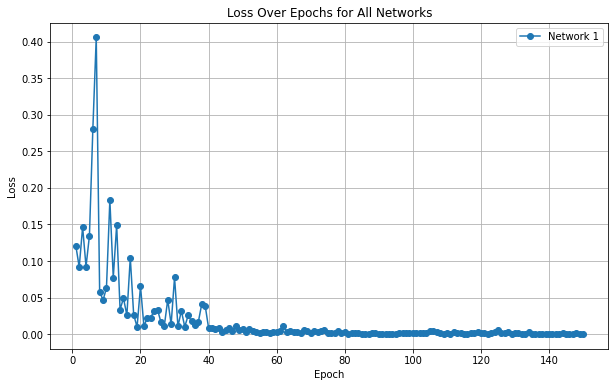

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.4044
Epoch 2/150
Epoch [2], Loss: 0.1650
Epoch 3/150
Epoch [3], Loss: 0.5108
Epoch 4/150
Epoch [4], Loss: 0.1567
Epoch 5/150
Epoch [5], Loss: 0.1393
Epoch 6/150
Epoch [6], Loss: 0.0641
Epoch 7/150
Epoch [7], Loss: 0.0650
Epoch 8/150
Epoch [8], Loss: 0.0469
Epoch 9/150
Epoch [9], Loss: 0.0739
Epoch 10/150
Epoch [10], Loss: 0.0755
Epoch 11/150
Epoch [11], Loss: 0.1227
Epoch 12/150
Epoch [12], Loss: 0.0756
Epoch 13/150
Epoch [13], Loss: 0.1212
Epoch 14/150
Epoch [14], Loss: 0.1070
Epoch 15/150
Epoch [15], Loss: 0.0218
Epoch 16/150
Epoch [16], Loss: 0.0710
Epoch 17/150
Epoch [17], Loss: 0.0570
Epoch 18/150
Epoch [18], Loss: 0.0195
Epoch 19/150
Epoch [19], Loss: 0.0317
Epoch 20/150
Epoch [20], Loss: 0.0250
Epoch 21/150
Epoch [21], Loss: 0.0499
Epoch 22/150
Epoch [22], Loss: 0.0751
Epoch 23/150
Epoch [23], Loss: 0.0422
Epoch 24/150
Epoch [24], Loss: 0.0692
Epoch 25/150
Epoch [25], Loss: 0.0566
Epoch 26/150
Epoch [26], Loss: 0.0427
Epoch 27/15

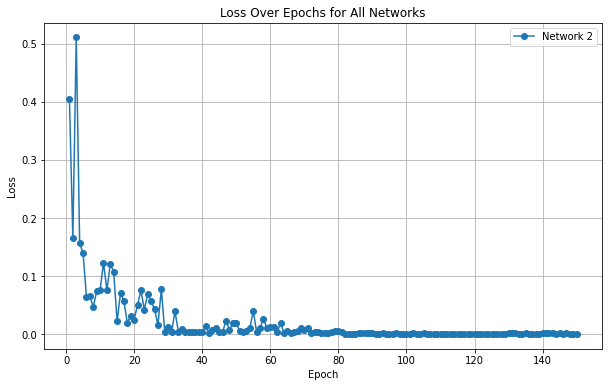

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.6294
Epoch 2/150
Epoch [2], Loss: 0.1203
Epoch 3/150
Epoch [3], Loss: 0.5511
Epoch 4/150
Epoch [4], Loss: 0.1520
Epoch 5/150
Epoch [5], Loss: 0.5337
Epoch 6/150
Epoch [6], Loss: 0.1800
Epoch 7/150
Epoch [7], Loss: 0.1492
Epoch 8/150
Epoch [8], Loss: 0.0984
Epoch 9/150
Epoch [9], Loss: 0.0539
Epoch 10/150
Epoch [10], Loss: 0.0346
Epoch 11/150
Epoch [11], Loss: 0.1695
Epoch 12/150
Epoch [12], Loss: 0.0464
Epoch 13/150
Epoch [13], Loss: 0.0265
Epoch 14/150
Epoch [14], Loss: 0.0826
Epoch 15/150
Epoch [15], Loss: 0.0375
Epoch 16/150
Epoch [16], Loss: 0.0513
Epoch 17/150
Epoch [17], Loss: 0.0134
Epoch 18/150
Epoch [18], Loss: 0.0249
Epoch 19/150
Epoch [19], Loss: 0.0568
Epoch 20/150
Epoch [20], Loss: 0.0059
Epoch 21/150
Epoch [21], Loss: 0.0106
Epoch 22/150
Epoch [22], Loss: 0.0253
Epoch 23/150
Epoch [23], Loss: 0.0096
Epoch 24/150
Epoch [24], Loss: 0.0308
Epoch 25/150
Epoch [25], Loss: 0.1096
Epoch 26/150
Epoch [26], Loss: 0.0679
Epoch 27/15

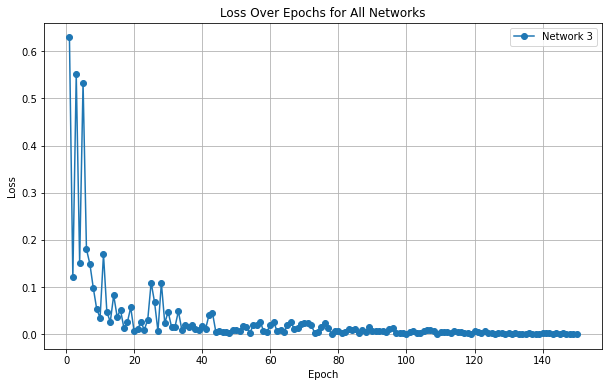

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.6600
Epoch 2/150
Epoch [2], Loss: 0.2016
Epoch 3/150
Epoch [3], Loss: 0.3931
Epoch 4/150
Epoch [4], Loss: 0.1785
Epoch 5/150
Epoch [5], Loss: 0.0926
Epoch 6/150
Epoch [6], Loss: 0.1014
Epoch 7/150
Epoch [7], Loss: 0.0780
Epoch 8/150
Epoch [8], Loss: 0.1618
Epoch 9/150
Epoch [9], Loss: 0.0323
Epoch 10/150
Epoch [10], Loss: 0.0545
Epoch 11/150
Epoch [11], Loss: 0.0470
Epoch 12/150
Epoch [12], Loss: 0.1004
Epoch 13/150
Epoch [13], Loss: 0.2011
Epoch 14/150
Epoch [14], Loss: 0.0371
Epoch 15/150
Epoch [15], Loss: 0.1455
Epoch 16/150
Epoch [16], Loss: 0.0959
Epoch 17/150
Epoch [17], Loss: 0.0506
Epoch 18/150
Epoch [18], Loss: 0.0164
Epoch 19/150
Epoch [19], Loss: 0.0124
Epoch 20/150
Epoch [20], Loss: 0.0172
Epoch 21/150
Epoch [21], Loss: 0.0154
Epoch 22/150
Epoch [22], Loss: 0.0578
Epoch 23/150
Epoch [23], Loss: 0.0432
Epoch 24/150
Epoch [24], Loss: 0.0144
Epoch 25/150
Epoch [25], Loss: 0.0549
Epoch 26/150
Epoch [26], Loss: 0.0518
Epoch 27/15

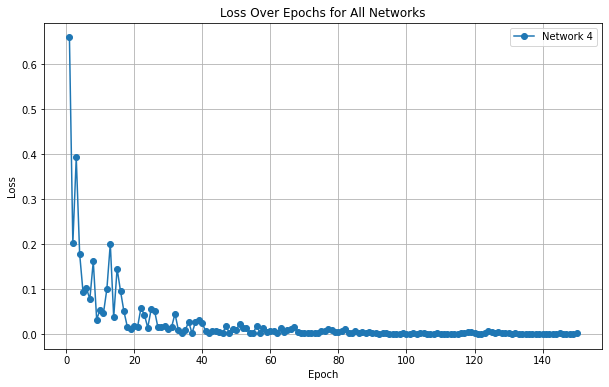

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.2188
Epoch 2/150
Epoch [2], Loss: 0.4704
Epoch 3/150
Epoch [3], Loss: 0.4483
Epoch 4/150
Epoch [4], Loss: 0.1013
Epoch 5/150
Epoch [5], Loss: 0.1151
Epoch 6/150
Epoch [6], Loss: 0.1680
Epoch 7/150
Epoch [7], Loss: 0.0825
Epoch 8/150
Epoch [8], Loss: 0.3910
Epoch 9/150
Epoch [9], Loss: 0.2319
Epoch 10/150
Epoch [10], Loss: 0.2102
Epoch 11/150
Epoch [11], Loss: 0.1168
Epoch 12/150
Epoch [12], Loss: 0.1472
Epoch 13/150
Epoch [13], Loss: 0.1481
Epoch 14/150
Epoch [14], Loss: 0.0180
Epoch 15/150
Epoch [15], Loss: 0.0416
Epoch 16/150
Epoch [16], Loss: 0.0284
Epoch 17/150
Epoch [17], Loss: 0.0851
Epoch 18/150
Epoch [18], Loss: 0.0188
Epoch 19/150
Epoch [19], Loss: 0.0174
Epoch 20/150
Epoch [20], Loss: 0.0172
Epoch 21/150
Epoch [21], Loss: 0.0089
Epoch 22/150
Epoch [22], Loss: 0.0148
Epoch 23/150
Epoch [23], Loss: 0.0150
Epoch 24/150
Epoch [24], Loss: 0.0142
Epoch 25/150
Epoch [25], Loss: 0.0256
Epoch 26/150
Epoch [26], Loss: 0.0133
Epoch 27/15

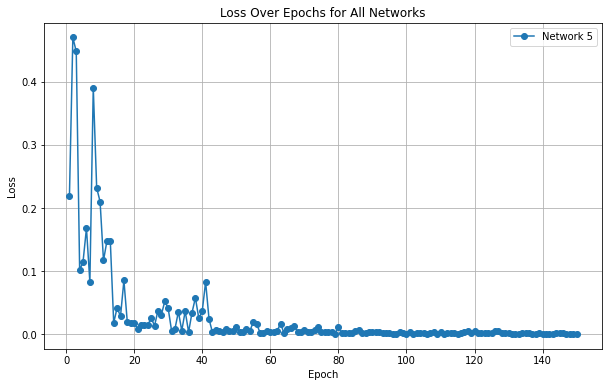

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.5367
Epoch 2/150
Epoch [2], Loss: 0.3090
Epoch 3/150
Epoch [3], Loss: 0.1357
Epoch 4/150
Epoch [4], Loss: 0.2291
Epoch 5/150
Epoch [5], Loss: 0.0876
Epoch 6/150
Epoch [6], Loss: 0.4150
Epoch 7/150
Epoch [7], Loss: 0.1450
Epoch 8/150
Epoch [8], Loss: 0.0451
Epoch 9/150
Epoch [9], Loss: 0.0529
Epoch 10/150
Epoch [10], Loss: 0.1086
Epoch 11/150
Epoch [11], Loss: 0.1472
Epoch 12/150
Epoch [12], Loss: 0.1020
Epoch 13/150
Epoch [13], Loss: 0.1036
Epoch 14/150
Epoch [14], Loss: 0.0308
Epoch 15/150
Epoch [15], Loss: 0.0437
Epoch 16/150
Epoch [16], Loss: 0.0921
Epoch 17/150
Epoch [17], Loss: 0.0158
Epoch 18/150
Epoch [18], Loss: 0.0348
Epoch 19/150
Epoch [19], Loss: 0.0141
Epoch 20/150
Epoch [20], Loss: 0.0850
Epoch 21/150
Epoch [21], Loss: 0.0133
Epoch 22/150
Epoch [22], Loss: 0.0920
Epoch 23/150
Epoch [23], Loss: 0.0205
Epoch 24/150
Epoch [24], Loss: 0.0361
Epoch 25/150
Epoch [25], Loss: 0.0579
Epoch 26/150
Epoch [26], Loss: 0.0973
Epoch 27/15

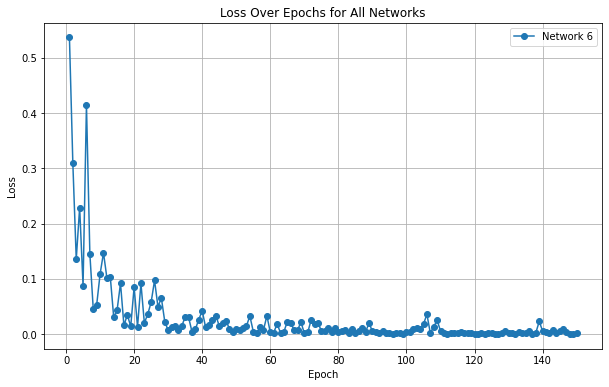

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.3306
Epoch 2/150
Epoch [2], Loss: 0.2409
Epoch 3/150
Epoch [3], Loss: 0.3781
Epoch 4/150
Epoch [4], Loss: 0.3838
Epoch 5/150
Epoch [5], Loss: 0.0769
Epoch 6/150
Epoch [6], Loss: 0.1138
Epoch 7/150
Epoch [7], Loss: 0.2716
Epoch 8/150
Epoch [8], Loss: 0.0816
Epoch 9/150
Epoch [9], Loss: 0.0452
Epoch 10/150
Epoch [10], Loss: 0.0869
Epoch 11/150
Epoch [11], Loss: 0.0318
Epoch 12/150
Epoch [12], Loss: 0.0558
Epoch 13/150
Epoch [13], Loss: 0.0527
Epoch 14/150
Epoch [14], Loss: 0.1040
Epoch 15/150
Epoch [15], Loss: 0.0160
Epoch 16/150
Epoch [16], Loss: 0.0321
Epoch 17/150
Epoch [17], Loss: 0.0682
Epoch 18/150
Epoch [18], Loss: 0.0302
Epoch 19/150
Epoch [19], Loss: 0.0338
Epoch 20/150
Epoch [20], Loss: 0.0690
Epoch 21/150
Epoch [21], Loss: 0.0900
Epoch 22/150
Epoch [22], Loss: 0.0675
Epoch 23/150
Epoch [23], Loss: 0.0462
Epoch 24/150
Epoch [24], Loss: 0.0636
Epoch 25/150
Epoch [25], Loss: 0.0428
Epoch 26/150
Epoch [26], Loss: 0.0818
Epoch 27/15

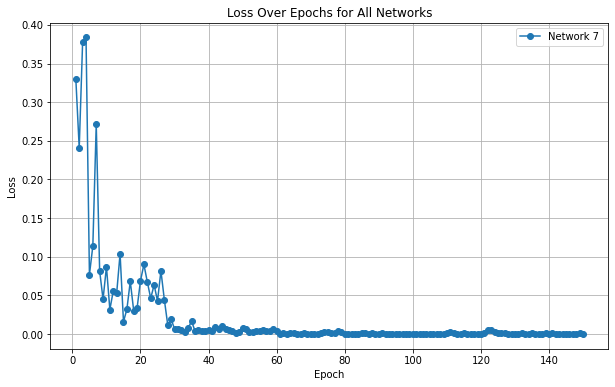

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.1447
Epoch 2/150
Epoch [2], Loss: 0.2173
Epoch 3/150
Epoch [3], Loss: 0.1664
Epoch 4/150
Epoch [4], Loss: 0.1361
Epoch 5/150
Epoch [5], Loss: 0.1267
Epoch 6/150
Epoch [6], Loss: 0.1787
Epoch 7/150
Epoch [7], Loss: 0.0574
Epoch 8/150
Epoch [8], Loss: 0.0732
Epoch 9/150
Epoch [9], Loss: 0.2521
Epoch 10/150
Epoch [10], Loss: 0.0481
Epoch 11/150
Epoch [11], Loss: 0.0492
Epoch 12/150
Epoch [12], Loss: 0.0419
Epoch 13/150
Epoch [13], Loss: 0.0505
Epoch 14/150
Epoch [14], Loss: 0.1105
Epoch 15/150
Epoch [15], Loss: 0.0351
Epoch 16/150
Epoch [16], Loss: 0.0175
Epoch 17/150
Epoch [17], Loss: 0.0484
Epoch 18/150
Epoch [18], Loss: 0.0721
Epoch 19/150
Epoch [19], Loss: 0.0827
Epoch 20/150
Epoch [20], Loss: 0.0437
Epoch 21/150
Epoch [21], Loss: 0.0648
Epoch 22/150
Epoch [22], Loss: 0.0530
Epoch 23/150
Epoch [23], Loss: 0.0499
Epoch 24/150
Epoch [24], Loss: 0.0151
Epoch 25/150
Epoch [25], Loss: 0.0251
Epoch 26/150
Epoch [26], Loss: 0.0206
Epoch 27/15

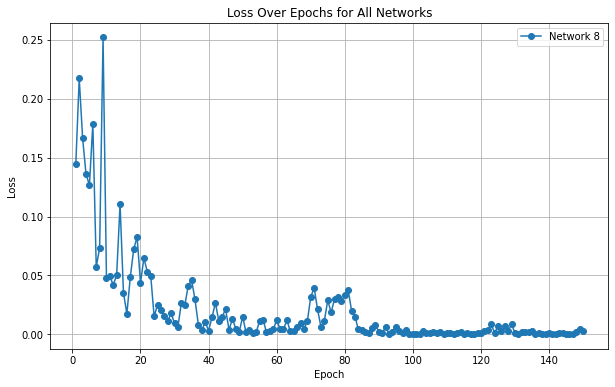

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.2033
Epoch 2/150
Epoch [2], Loss: 0.1978
Epoch 3/150
Epoch [3], Loss: 0.1308
Epoch 4/150
Epoch [4], Loss: 0.1622
Epoch 5/150
Epoch [5], Loss: 0.5687
Epoch 6/150
Epoch [6], Loss: 0.2290
Epoch 7/150
Epoch [7], Loss: 0.0589
Epoch 8/150
Epoch [8], Loss: 0.2156
Epoch 9/150
Epoch [9], Loss: 0.1719
Epoch 10/150
Epoch [10], Loss: 0.0629
Epoch 11/150
Epoch [11], Loss: 0.0514
Epoch 12/150
Epoch [12], Loss: 0.3199
Epoch 13/150
Epoch [13], Loss: 0.0404
Epoch 14/150
Epoch [14], Loss: 0.0313
Epoch 15/150
Epoch [15], Loss: 0.1120
Epoch 16/150
Epoch [16], Loss: 0.0973
Epoch 17/150
Epoch [17], Loss: 0.0733
Epoch 18/150
Epoch [18], Loss: 0.0665
Epoch 19/150
Epoch [19], Loss: 0.1098
Epoch 20/150
Epoch [20], Loss: 0.0647
Epoch 21/150
Epoch [21], Loss: 0.0437
Epoch 22/150
Epoch [22], Loss: 0.0862
Epoch 23/150
Epoch [23], Loss: 0.0320
Epoch 24/150
Epoch [24], Loss: 0.0632
Epoch 25/150
Epoch [25], Loss: 0.0172
Epoch 26/150
Epoch [26], Loss: 0.0820
Epoch 27/15

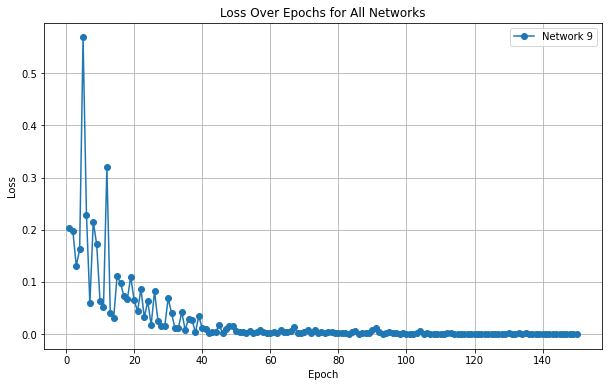

Training Network 1
Epoch 1/150
Epoch [1], Loss: 0.1551
Epoch 2/150
Epoch [2], Loss: 0.1694
Epoch 3/150
Epoch [3], Loss: 0.1754
Epoch 4/150
Epoch [4], Loss: 0.1227
Epoch 5/150
Epoch [5], Loss: 0.3097
Epoch 6/150
Epoch [6], Loss: 0.1591
Epoch 7/150
Epoch [7], Loss: 0.0596
Epoch 8/150
Epoch [8], Loss: 0.0641
Epoch 9/150
Epoch [9], Loss: 0.0620
Epoch 10/150
Epoch [10], Loss: 0.3864
Epoch 11/150
Epoch [11], Loss: 0.2186
Epoch 12/150
Epoch [12], Loss: 0.0463
Epoch 13/150
Epoch [13], Loss: 0.0790
Epoch 14/150
Epoch [14], Loss: 0.1073
Epoch 15/150
Epoch [15], Loss: 0.0373
Epoch 16/150
Epoch [16], Loss: 0.0259
Epoch 17/150
Epoch [17], Loss: 0.0375
Epoch 18/150
Epoch [18], Loss: 0.0866
Epoch 19/150
Epoch [19], Loss: 0.0212
Epoch 20/150
Epoch [20], Loss: 0.1042
Epoch 21/150
Epoch [21], Loss: 0.0590
Epoch 22/150
Epoch [22], Loss: 0.0169
Epoch 23/150
Epoch [23], Loss: 0.0123
Epoch 24/150
Epoch [24], Loss: 0.0469
Epoch 25/150
Epoch [25], Loss: 0.0786
Epoch 26/150
Epoch [26], Loss: 0.0188
Epoch 27/15

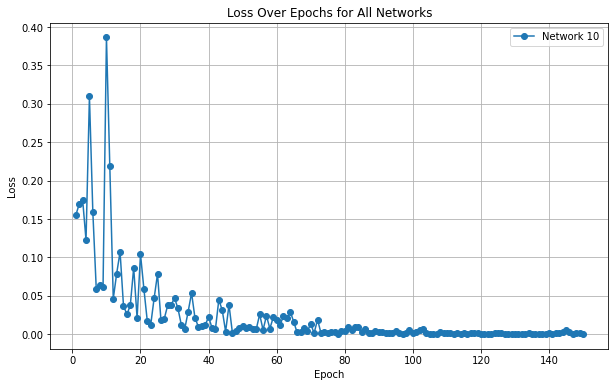

Successfully trained 10 networks.
Attemps:0, successfull networks: 10


In [53]:
loss_fn = MSELoss()

analyzer = NetworkAnalyzer(model_architecture=LargerNet, amount_to_produce=10, success_loss=0.1, convergence_threshold=1, max_attempts=10)
analyzer.generate_networks(train_loader=train_loader, test_loader=test_loader, num_epochs=150, loss_fn=loss_fn)


In [54]:
import importlib.util
import os
import json
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from largerNetArchitecture import LargerNet

In [55]:
NUM_BINS = 100

working_networks_path = "WorkingNetworks/working_networks.pt"
broken_networks_path = "BrokenNetworks/broken_networks.pt"

#Load in the networks
loaded_state_dict = torch.load(working_networks_path)

#create new instantiations to contain the saved networks
num_networks = len(loaded_state_dict)
networks = []
for n in range(num_networks):
    networks.append(LargerNet())

for i, network in enumerate(networks):
    state_dict_key = f'network_{i+1}'
    network.load_state_dict(loaded_state_dict[state_dict_key])




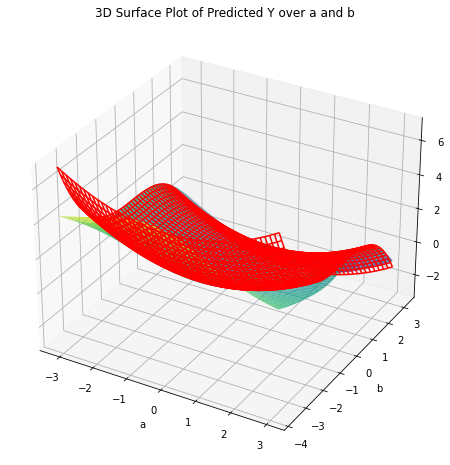

In [56]:
from mpl_toolkits.mplot3d import Axes3D

def target_function(a, b):
    return (1/5) * a**2 - (1/10) * b**3


# Create a grid of values
a_range = np.linspace(a_tensor.min(), a_tensor.max(), 50)
b_range = np.linspace(b_tensor.min(), b_tensor.max(), 50)
A, B = np.meshgrid(a_range, b_range)
grid = np.c_[A.ravel(), B.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Get predictions
network.eval()
with torch.no_grad():
    y_pred_grid = network(grid_tensor).numpy()

# Reshape predictions to match grid
Y_pred_grid = y_pred_grid.reshape(A.shape)

# Plot the surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, Y_pred_grid, cmap='viridis', alpha=0.8)

# Optionally plot the actual target function for comparison
# Compute actual Y values using the target function
Y_actual_grid = target_function(A, B)

# Plot the actual surface
ax.plot_wireframe(A, B, Y_actual_grid, color='r', label='Actual Function')

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('Predicted Y')
plt.title('3D Surface Plot of Predicted Y over a and b')
plt.show()
